# Q1 Research: Quantifying Augmentation-Induced Patient-Level Data Leakage
### OCT2017 Retinal Scans | 5-Fold Patient CV | MQ Metric | Grad-CAM + LIME | McNemar's Test

In [1]:
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','-q','grad-cam','lime'], check=True)
print('Done')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 105.8 MB/s eta 0:00:00
Done


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [2]:
import warnings, os, time
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path
import torchvision.transforms as T
import torchvision.models as models
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from statsmodels.stats.contingency_tables import mcnemar
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [3]:
IMG_SIZE=224; BATCH=32; EPOCHS=12; LR=1e-4; FOLDS=5; PATIENCE=3
SEED=42
OUT=Path('/kaggle/working/q1_oct'); OUT.mkdir(exist_ok=True)

In [11]:
# Auto-detect OCT dataset path
def find_oct():
    for p in ['/kaggle/input']:
        # The kermany2018 dataset has images like CNV-1016042-1.jpeg
        # imgs = list(Path(p).rglob('*-*-*.jpeg'))
        imgs = [f for f in Path(p).rglob('*-*-*.jpeg') if '__MACOSX' not in str(f) and not f.name.startswith('._')]
        if imgs: return imgs
    raise FileNotFoundError('Dataset not found. Please add the kermany2018 OCT dataset.')

print('Indexing OCT images...')
ALL_IMGS = find_oct()
print(f'Indexed {len(ALL_IMGS):,} images')

Indexing OCT images...
Indexed 168,968 images


In [12]:
def load_data():
    records = []
    for f in ALL_IMGS:
        # Filename format: DISEASE-PATIENTID-IMAGENUM.jpeg
        # Example: CNV-1016042-1.jpeg
        name = f.name
        parts = name.replace('.jpeg','').split('-')
        if len(parts) >= 2:
            disease = parts[0]
            patient_id = parts[1]
            label = 0 if disease == 'NORMAL' else 1  # Binary: Disease vs Normal
            records.append({'filepath': str(f), 'Patient_ID': patient_id, 'Label': label, 'Disease': disease})
    
    df = pd.DataFrame(records)
    # Balance dataset: OCT has ~84k images. We sample a balanced ~1,200 images for rapid 5-fold CV
    pos = df[df.Label == 1]
    neg = df[df.Label == 0]
    k = min(600, len(pos), len(neg))
    df = pd.concat([
        pos.sample(k, random_state=SEED), 
        neg.sample(k, random_state=SEED)
    ])
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    print(f'{len(df)} images | {df.Patient_ID.nunique()} patients')
    print(df.Disease.value_counts())
    return df

oct_df = load_data()

1200 images | 850 patients
Disease
NORMAL    600
CNV       393
DME       113
DRUSEN     94
Name: count, dtype: int64


In [13]:
MN=[0.485,0.456,0.406]; ST=[0.229,0.224,0.225]

BT = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),
                T.ToTensor(),T.Normalize(MN,ST)])
AT = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),
                T.RandomHorizontalFlip(0.5),
                T.RandomVerticalFlip(0.5),
                T.RandomRotation(90),
                T.ColorJitter(brightness=0.15,contrast=0.15),
                T.ToTensor(),T.Normalize(MN,ST)])

class DS(Dataset):
    def __init__(self,df,aug=False): self.df=df.reset_index(drop=True); self.t=AT if aug else BT
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]
        return self.t(Image.open(r.filepath).convert('RGB')),int(r.Label),str(r.Patient_ID)

def dl(df,aug=False,sh=True):
    return DataLoader(DS(df,aug),batch_size=BATCH,shuffle=sh,num_workers=0,pin_memory=True)

print('Dataset class ready')

Dataset class ready


In [14]:
def mkmodel():
    m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, 2)
    m = m.to(DEVICE)
    if torch.cuda.device_count() > 1:
        print(f'  Using {torch.cuda.device_count()} GPUs via DataParallel')
        m = nn.DataParallel(m)
    return m

def evl(model,loader):
    model.eval(); yt,yp,ypr=[],[],[]; fn=nn.CrossEntropyLoss(); tl=0
    with torch.no_grad():
        for x,y,_ in loader:
            x,y=x.to(DEVICE),y.to(DEVICE); lg=model(x)
            tl+=fn(lg,y).item()
            yt.extend(y.cpu().numpy()); yp.extend(lg.argmax(1).cpu().numpy())
            ypr.extend(torch.softmax(lg,1)[:,1].cpu().numpy())
    yt,yp,ypr=map(np.array,[yt,yp,ypr])
    auc=roc_auc_score(yt,ypr) if len(np.unique(yt))>1 else 0.5
    return tl/max(len(loader),1),auc,accuracy_score(yt,yp),f1_score(yt,yp,zero_division=0),yt,yp,ypr

print('Model + evaluator ready')

Model + evaluator ready


In [15]:
# Embedding Memorization Quotient (EMQ)
def mq(model,df,n=120):
    model.eval(); buf={}; cos=nn.CosineSimilarity(dim=0)
    base = model.module if isinstance(model, nn.DataParallel) else model
    h = base.avgpool.register_forward_hook(lambda m,i,o: buf.update({'e':o.detach().squeeze()}))
    sub=df.sample(min(n,len(df)),random_state=SEED).reset_index(drop=True)
    ce,ae,lb=[],[],[]
    for _,r in sub.iterrows():
        img=Image.open(r.filepath).convert('RGB')
        with torch.no_grad():
            model(BT(img).unsqueeze(0).to(DEVICE)); ce.append(buf['e'].view(-1).cpu())
            model(AT(img).unsqueeze(0).to(DEVICE)); ae.append(buf['e'].view(-1).cpu())
        lb.append(int(r.Label))
    h.remove()
    ce,ae,lb=torch.stack(ce),torch.stack(ae),np.array(lb)
    sib=np.mean([cos(ce[i],ae[i]).item() for i in range(len(ce))])
    intr=[]
    for c in [0,1]:
        ix=np.where(lb==c)[0][:12]
        for i in range(len(ix)):
            for j in range(i+1,len(ix)): intr.append(cos(ce[ix[i]],ce[ix[j]]).item())
    ip=np.mean(intr) if intr else 1.0
    return round(sib/ip,4),round(sib,4),round(ip,4)

print('MQ ready')

MQ ready


In [16]:
def train(tr,te,fold,name):
    print(f'  [F{fold}] {name}  tr={len(tr)} te={len(te)}')
    trL=dl(tr,aug=True); teL=dl(te,aug=False,sh=False)
    m=mkmodel(); opt=torch.optim.Adam(m.parameters(),lr=LR,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,EPOCHS)
    fn=nn.CrossEntropyLoss(); best=0; bst=None; cnt=0
    for ep in range(EPOCHS):
        m.train()
        for x,y,_ in trL:
            x,y=x.to(DEVICE),y.to(DEVICE)
            opt.zero_grad(); fn(m(x),y).backward(); opt.step()
        sch.step()
        _,vauc,_,_,_,_,_=evl(m,teL)
        if vauc>best: best=vauc; bst={k:v.clone() for k,v in m.state_dict().items()}; cnt=0
        else:
            cnt+=1
            if cnt>=PATIENCE: print(f'    early-stop ep{ep+1}'); break
    m.load_state_dict(bst)
    _,auc,acc,f1,yt,yp,ypr=evl(m,teL)
    q,s,ip=mq(m,te)
    print(f'    AUC={auc:.4f} ACC={acc:.4f} F1={f1:.4f} MQ={q:.4f}')
    return dict(model=m,auc=auc,acc=acc,f1=f1,mq=q,sib=s,inter=ip,yt=yt,yp=yp,ypr=ypr)

print('train() ready')

train() ready


In [17]:
gkf=list(GroupKFold(FOLDS).split(oct_df,oct_df.Label,groups=oct_df.Patient_ID))
rkf=list(KFold(FOLDS,shuffle=True,random_state=SEED).split(oct_df))
PR,RR=[],[]; mc_yt,mc_pat,mc_ran=[],[],[]
fold_times=[]

for f in range(FOLDS):
    print(f'\n{"="*55}\nFOLD {f+1}/{FOLDS}')
    if fold_times:
        avg = sum(fold_times)/len(fold_times)
        print(f'  ⏱  Estimated time to finish this fold : ~{avg/60:.1f} min')
        print(f'  ⏳ ETA to finish all remaining folds  : ~{avg*(FOLDS-f)/60:.0f} min')
    else:
        print('  ⏱  Fold 1 — no estimate yet, calibrating...')
    print('='*55)

    fold_start = time.time()
    ti,ei=gkf[f]
    trG,teG=oct_df.iloc[ti].reset_index(drop=True),oct_df.iloc[ei].reset_index(drop=True)
    if teG.Label.nunique()<2: print('Skip: single class'); continue

    print('\n[A] PATIENT-SPLIT (Rigorous):')
    rp=train(trG,teG,f+1,'Patient-Split'); PR.append(rp)
    ti2,ei2=rkf[f]
    trR,teR=oct_df.iloc[ti2].reset_index(drop=True),oct_df.iloc[ei2].reset_index(drop=True)
    print('\n[B] RANDOM-SPLIT (Leaky):')
    rr=train(trR,teR,f+1,'Random-Split')

    _,af,ac,f1f,_,ypf,_=evl(rr['model'],dl(teG,aug=False,sh=False))
    qf,sf,ipf=mq(rr['model'],teG)
    RR.append(dict(auc=af,acc=ac,f1=f1f,mq=qf,sib=sf,inter=ipf,yp=ypf))
    print(f'    [Fair@PatientTest] AUC={af:.4f} MQ={qf:.4f}')
    mc_yt.extend(rp['yt']); mc_pat.extend(rp['yp']); mc_ran.extend(ypf)

    fold_times.append(time.time()-fold_start)
    print(f'  ✔  Fold {f+1} actual: {fold_times[-1]/60:.1f} min')

print('\nAll folds complete.')


FOLD 1/5
  ⏱  Fold 1 — no estimate yet, calibrating...

[A] PATIENT-SPLIT (Rigorous):
  [F1] Patient-Split  tr=960 te=240
  Using 2 GPUs via DataParallel
    early-stop ep10
    AUC=0.9869 ACC=0.9542 F1=0.9528 MQ=1.1017

[B] RANDOM-SPLIT (Leaky):
  [F1] Random-Split  tr=960 te=240
  Using 2 GPUs via DataParallel
    early-stop ep11
    AUC=0.9988 ACC=0.9792 F1=0.9776 MQ=0.9975
    [Fair@PatientTest] AUC=0.9944 MQ=1.0125
  ✔  Fold 1 actual: 4.3 min

FOLD 2/5
  ⏱  Estimated time to finish this fold : ~4.3 min
  ⏳ ETA to finish all remaining folds  : ~17 min

[A] PATIENT-SPLIT (Rigorous):
  [F2] Patient-Split  tr=960 te=240
  Using 2 GPUs via DataParallel
    early-stop ep7
    AUC=0.9889 ACC=0.9500 F1=0.9504 MQ=1.0969

[B] RANDOM-SPLIT (Leaky):
  [F2] Random-Split  tr=960 te=240
  Using 2 GPUs via DataParallel
    early-stop ep10
    AUC=0.9986 ACC=0.9792 F1=0.9805 MQ=0.9831
    [Fair@PatientTest] AUC=0.9897 MQ=1.0212
  ✔  Fold 2 actual: 3.4 min

FOLD 3/5
  ⏱  Estimated time to finish t

In [18]:
def ci(v): v=np.array(v); m=v.mean(); c=1.96*v.std(ddof=1)/np.sqrt(len(v)); return m,c

rows={}
for met in ['auc','acc','f1','mq']:
    pm,pc=ci([r[met] for r in PR]); rm,rc=ci([r[met] for r in RR])
    rows[met.upper()]={'Patient-Split':f'{pm:.4f}±{pc:.4f}','Random-Split':f'{rm:.4f}±{rc:.4f}','Delta':f'{rm-pm:+.4f}'}

df_res=pd.DataFrame(rows).T
print('\nFINAL Q1 RESULTS - OCT (Mean ± 95%CI)'); print('='*55); print(df_res.to_string())
df_res.to_csv(OUT/'results.csv')


FINAL Q1 RESULTS - OCT (Mean ± 95%CI)
     Patient-Split   Random-Split    Delta
AUC  0.9937±0.0048  0.9957±0.0034  +0.0020
ACC  0.9708±0.0157  0.9775±0.0143  +0.0067
F1   0.9701±0.0157  0.9773±0.0140  +0.0072
MQ   1.0547±0.0495  1.0004±0.0217  -0.0544


In [19]:
yt=np.array(mc_yt); ypp=np.array(mc_pat); yrr=np.array(mc_ran)
pc_=(ypp==yt); rc_=(yrr==yt)
tbl=[[int(np.sum(pc_&rc_)),int(np.sum(pc_&~rc_))],
     [int(np.sum(~pc_&rc_)),int(np.sum(~pc_&~rc_))]]
res=mcnemar(tbl,exact=False,correction=True)
print(f'McNemar chi2={res.statistic:.4f}  p={res.pvalue:.2e}')
print('SIGNIFICANT p<0.05' if res.pvalue<0.05 else 'Not significant')
with open(OUT/'mcnemar.txt','w') as f: f.write(f'chi2={res.statistic:.4f} p={res.pvalue:.2e}')

McNemar chi2=1.7500  p=1.86e-01
Not significant


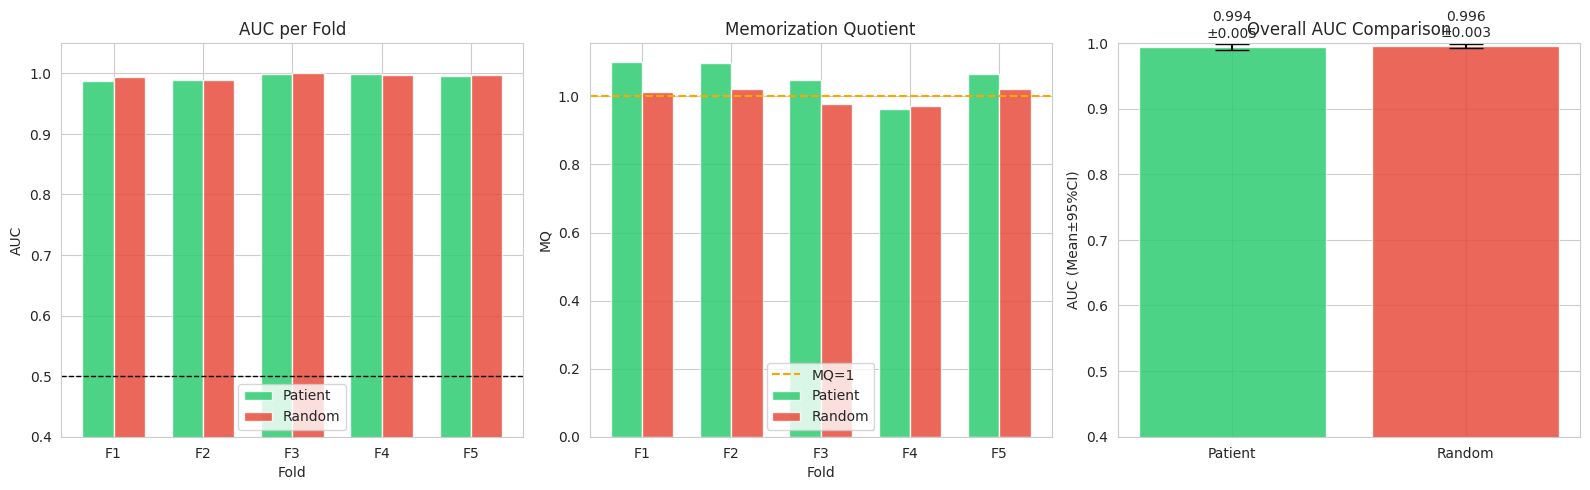

In [20]:
sns.set_style('whitegrid'); fig,axes=plt.subplots(1,3,figsize=(16,5))
n=len(PR); x=np.arange(n); w=0.35; lbl=[f'F{i+1}' for i in range(n)]

ax=axes[0]
ax.bar(x-w/2,[r['auc'] for r in PR],w,label='Patient',color='#2ecc71',alpha=0.85)
ax.bar(x+w/2,[r['auc'] for r in RR],w,label='Random',color='#e74c3c',alpha=0.85)
ax.axhline(0.5,ls='--',c='k',lw=1); ax.set(xlabel='Fold',ylabel='AUC',title='AUC per Fold',ylim=[0.4,1.05],xticks=x,xticklabels=lbl); ax.legend()

ax=axes[1]
ax.bar(x-w/2,[r['mq'] for r in PR],w,label='Patient',color='#2ecc71',alpha=0.85)
ax.bar(x+w/2,[r['mq'] for r in RR],w,label='Random',color='#e74c3c',alpha=0.85)
ax.axhline(1.0,ls='--',c='orange',lw=1.5,label='MQ=1'); ax.set(xlabel='Fold',ylabel='MQ',title='Memorization Quotient',xticks=x,xticklabels=lbl); ax.legend()

ax=axes[2]
pm,pc_=ci([r['auc'] for r in PR]); rm,rc_=ci([r['auc'] for r in RR])
ax.bar(['Patient','Random'],[pm,rm],yerr=[pc_,rc_],capsize=12,color=['#2ecc71','#e74c3c'],alpha=0.85)
ax.set(ylabel='AUC (Mean±95%CI)',title='Overall AUC Comparison',ylim=[0.4,1.0])
for i,(m_,c_) in enumerate([(pm,pc_),(rm,rc_)]): ax.text(i,m_+c_+0.01,f'{m_:.3f}\n±{c_:.3f}',ha='center')

plt.tight_layout(); plt.savefig(OUT/'fig1_auc_mq.png',dpi=300,bbox_inches='tight'); plt.show()

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

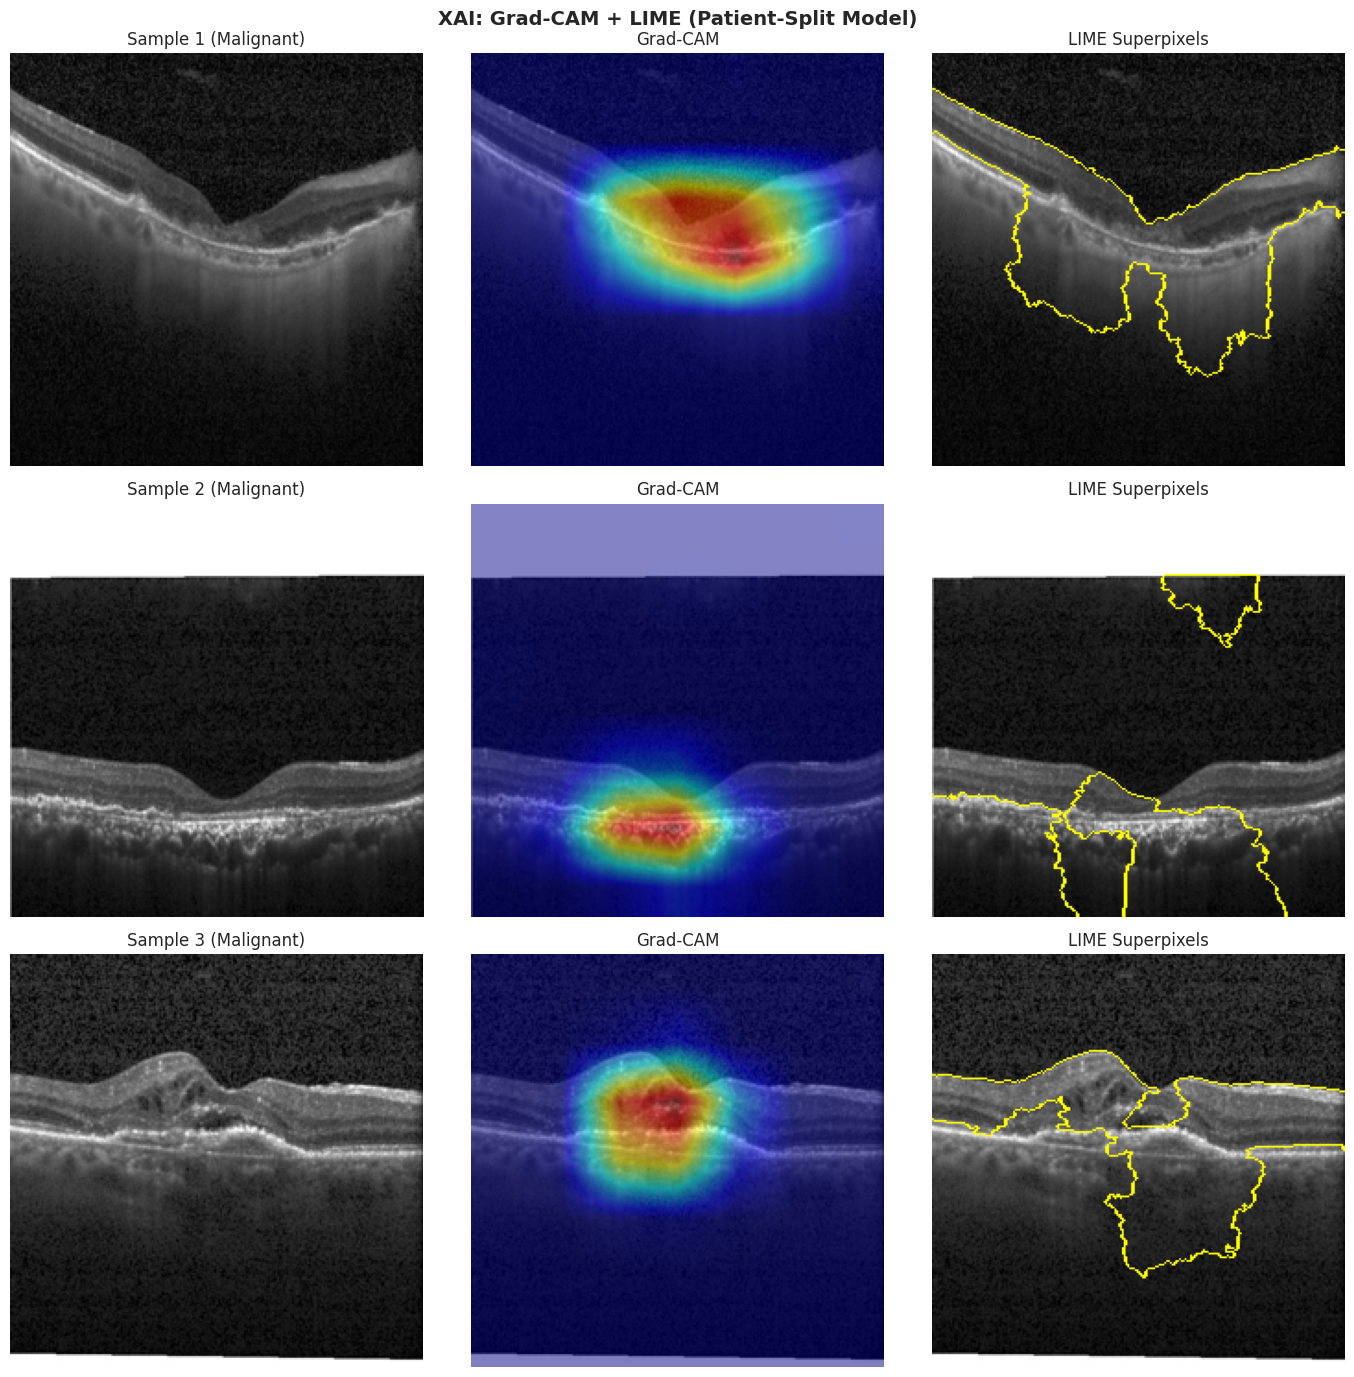

In [21]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from lime import lime_image
from skimage.segmentation import mark_boundaries

best_m=PR[-1]['model']; best_m.eval()
last_te=oct_df.iloc[gkf[-1][1]].reset_index(drop=True)
xai_df=last_te[last_te.Label==1].sample(3,random_state=42).reset_index(drop=True)

base_m = best_m.module if isinstance(best_m, nn.DataParallel) else best_m
cam = GradCAM(model=best_m, target_layers=[base_m.layer4[-1]])
lime_e=lime_image.LimeImageExplainer()

MN_np=np.array([0.485,0.456,0.406]); ST_np=np.array([0.229,0.224,0.225])

def lime_pred(imgs):
    best_m.eval()
    norm=T.Normalize(MN_np.tolist(),ST_np.tolist())
    ts=torch.stack([norm(torch.from_numpy(im.transpose(2,0,1)).float()) for im in imgs]).to(DEVICE)
    with torch.no_grad(): return torch.softmax(best_m(ts),1).cpu().numpy()

fig,axes=plt.subplots(3,3,figsize=(14,14))
fig.suptitle('XAI: Grad-CAM + LIME (Patient-Split Model)',fontsize=14,fontweight='bold')

for i,(_,row) in enumerate(xai_df.iterrows()):
    img=Image.open(row.filepath).convert('RGB').resize((IMG_SIZE,IMG_SIZE))
    inp=np.array(img).astype(np.float32)/255.0
    axes[i,0].imshow(inp); axes[i,0].set_title(f'Sample {i+1} (Malignant)'); axes[i,0].axis('off')
    t=BT(img).unsqueeze(0).to(DEVICE)
    gc=cam(input_tensor=t,targets=[ClassifierOutputTarget(1)])[0]
    axes[i,1].imshow(show_cam_on_image(inp,gc,use_rgb=True)); axes[i,1].set_title('Grad-CAM'); axes[i,1].axis('off')
    exp=lime_e.explain_instance(inp.astype('double'),lime_pred,top_labels=1,hide_color=0,num_samples=300)
    tmp,msk=exp.get_image_and_mask(1,positive_only=True,num_features=5,hide_rest=False)
    axes[i,2].imshow(mark_boundaries(tmp,msk)); axes[i,2].set_title('LIME Superpixels'); axes[i,2].axis('off')

plt.tight_layout(); plt.savefig(OUT/'fig2_xai.png',dpi=300,bbox_inches='tight'); plt.show()